<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_LAB1/Experiencia_4_Laboratorio_N%C2%B01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio N°1

In [33]:
# @title Importación, visualización, manipulación de datos
import pandas as pd
import sys
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import pickle
import time
import warnings
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, balanced_accuracy_score,
                              ConfusionMatrixDisplay, make_scorer, recall_score)
from sklearn.feature_selection import mutual_info_classif, RFECV, mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
import time
from itertools import combinations

---

## Experiencia 4: Sistema de control de acceso autónomo en espacios comerciales

**Dataset:** `datos_adl.csv`  

**Grupo 8:** — Alex Nahuel Acosta, Santiago Daniel Bareiro, Agustín Marcelo Borges

**Fecha:** — dd/mm/aaaa

---

> Sistema de seguridad basado en visión por computadora para instalaciones comerciales

---

### 0. Carga y exploración de datos

In [26]:
# Archivos pueden arrastrarse al área de trabajo o procesarse en local

# Version Online
!wget https://raw.githubusercontent.com/Santibareiro27/Inteligencia-Computacional/main/RA1_LAB1/datos_bmd.csv

--2026-04-16 19:39:25--  https://raw.githubusercontent.com/Santibareiro27/Inteligencia-Computacional/main/RA1_LAB1/datos_bmd.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50422 (49K) [text/plain]
Saving to: ‘datos_bmd.csv.2’

datos_bmd.csv.2     100%[===================>]  49.24K  --.-KB/s    in 0.01s   

2026-04-16 19:39:25 (4.00 MB/s) - ‘datos_bmd.csv.2’ saved [50422/50422]



In [27]:
# Lectura del dataset
dataset_bmd = pd.read_csv("datos_bmd.csv")
dataset_bmd

,Genero,Edad,CircunferenciaCabeza,AnchoHombro,AnchoPecho,Abdomen,Cintura,Cadera,LongitudBrazo,LongitudHombroCintura,LongitudCinturaRodilla,LongitudPierna,AlturaTotal
0,1.0,30,55.88,45.72,50.80,45.72,35.56,55.88,55.88,63.50,63.50,55.88,132.08
1,1.0,28,48.26,55.88,43.18,45.72,53.34,63.50,71.12,58.42,63.50,50.80,142.24
2,1.0,29,50.80,50.80,45.72,27.94,48.26,35.56,60.96,53.34,50.80,53.34,114.30
3,1.0,23,40.64,40.64,50.80,45.72,55.88,45.72,38.10,66.04,50.80,48.26,101.60
4,1.0,31,38.10,50.80,71.12,45.72,231.14,43.18,40.64,53.34,53.34,48.26,139.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
711,2.0,2,45.72,38.10,20.32,50.80,48.26,50.80,35.56,33.02,27.94,45.72,81.28
712,2.0,10,53.34,30.48,30.48,55.88,60.96,66.04,53.34,38.10,35.56,63.50,114.30
713,2.0,13,55.88,15.24,35.56,63.50,45.72,76.20,53.34,50.80,40.64,83.82,149.86
714,2.0,4,50.80,38.10,25.40,50.80,50.80,53.34,45.72,25.40,30.48,48.26,93.98


In [28]:
# 1. Información general y búsqueda de nulos
print("--- INFORMACIÓN GENERAL ---")
print(dataset_bmd.info())
print("\nValores nulos por columna:")
print(dataset_bmd.isnull().sum())

# 2. Estadísticas descriptivas
print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(dataset_bmd.describe())

--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716 entries, 0 to 715
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Genero                  715 non-null    float64
 1   Edad                    716 non-null    int64  
 2   CircunferenciaCabeza    716 non-null    float64
 3   AnchoHombro             716 non-null    float64
 4   AnchoPecho              716 non-null    float64
 5   Abdomen                 716 non-null    float64
 6   Cintura                 716 non-null    float64
 7   Cadera                  716 non-null    float64
 8   LongitudBrazo           716 non-null    float64
 9   LongitudHombroCintura   716 non-null    float64
 10  LongitudCinturaRodilla  716 non-null    float64
 11  LongitudPierna          716 non-null    float64
 12  AlturaTotal             716 non-null    float64
dtypes: float64(12), int64(1)
memory usage: 72.8 KB
None

Valores nulos 

,Genero,Edad,CircunferenciaCabeza,AnchoHombro,AnchoPecho,Abdomen,Cintura,Cadera,LongitudBrazo,LongitudHombroCintura,LongitudCinturaRodilla,LongitudPierna,AlturaTotal
count,715.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000
mean,1.453147,15.340782,52.258017,36.365279,37.007374,51.307291,48.934022,49.221369,47.795279,45.468128,42.062542,68.157849,122.221536
std,0.498148,11.831501,9.508118,12.095939,13.499202,25.737801,22.277594,22.212866,13.656543,13.663455,13.219205,20.132010,30.878074
min,1.000000,1.000000,12.700000,10.160000,15.240000,12.700000,5.080000,17.780000,15.240000,2.540000,10.160000,22.860000,48.260000
25%,1.000000,7.000000,48.260000,27.940000,27.940000,38.100000,30.480000,30.480000,40.640000,33.020000,33.020000,53.340000,101.600000
50%,1.000000,11.000000,50.800000,35.560000,33.020000,50.800000,50.800000,45.720000,48.260000,44.450000,40.640000,66.040000,121.920000
75%,2.000000,21.000000,55.880000,45.720000,43.180000,58.420000,58.420000,60.960000,55.880000,55.880000,50.800000,81.280000,139.700000
max,2.000000,68.000000,203.200000,220.980000,96.520000,541.020000,231.140000,160.020000,167.640000,99.060000,114.300000,127.000000,226.060000


Se decide eliminar la fila con el valor de genero nulo, porque es 1 fila respecto a 716.


In [29]:
dataset_bmd.dropna(subset=['Genero'], inplace=True)
print("Fila con valor nulo en 'Genero' eliminada.")
print("Valores nulos después de la eliminación:")
print(dataset_bmd.isnull().sum())

Fila con valor nulo en 'Genero' eliminada.
Valores nulos después de la eliminación:
Genero                    0
Edad                      0
CircunferenciaCabeza      0
AnchoHombro               0
AnchoPecho                0
Abdomen                   0
Cintura                   0
Cadera                    0
LongitudBrazo             0
LongitudHombroCintura     0
LongitudCinturaRodilla    0
LongitudPierna            0
AlturaTotal               0
dtype: int64


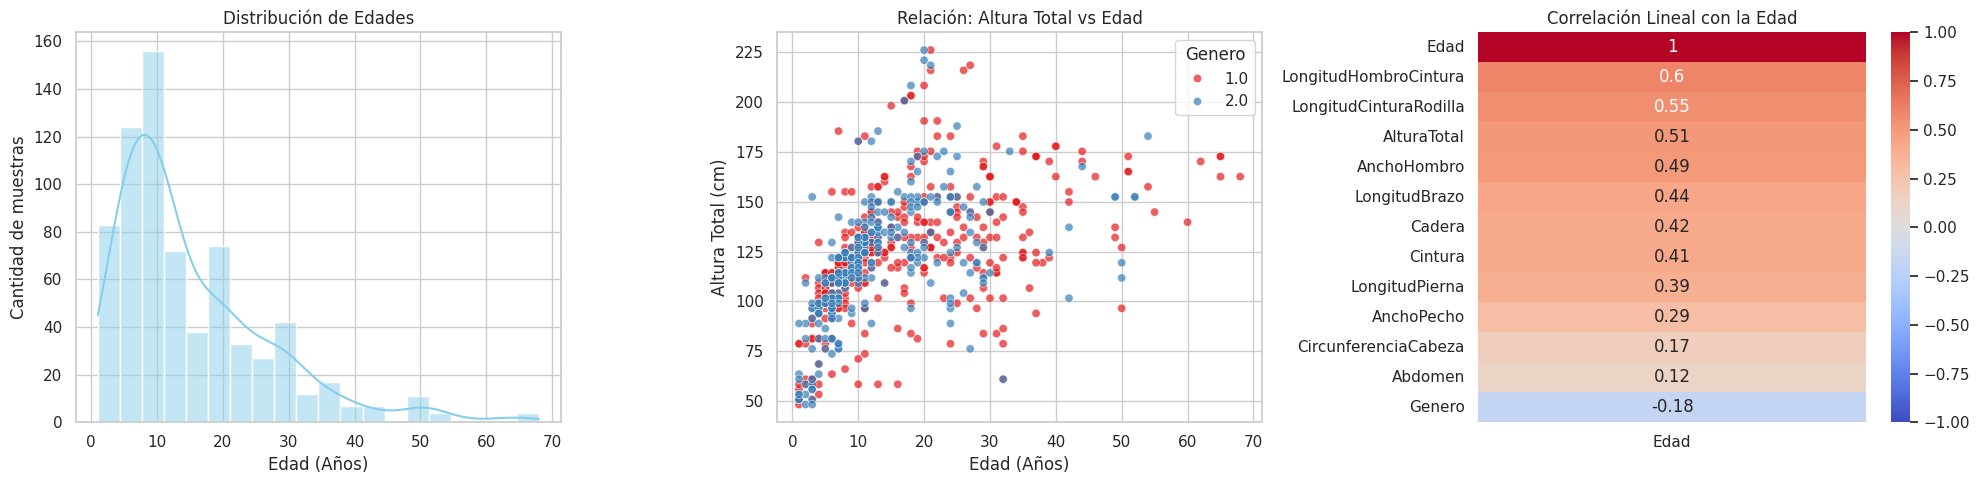

In [30]:
# Análisis visual de las distribuciones y relaciones
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Gráfico A: Distribución de las edades en el dataset
sns.histplot(data=dataset_bmd, x='Edad', bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edades')
axes[0].set_xlabel('Edad (Años)')
axes[0].set_ylabel('Cantidad de muestras')

# Gráfico B: Altura vs Edad (La relación más intuitiva)
sns.scatterplot(data=dataset_bmd, x='Edad', y='AlturaTotal', hue='Genero', palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title('Relación: Altura Total vs Edad')
axes[1].set_xlabel('Edad (Años)')
axes[1].set_ylabel('Altura Total (cm)')

# Gráfico C: Correlación de todas las variables con la Edad
correlaciones = dataset_bmd.corr()[['Edad']].sort_values(by='Edad', ascending=False)
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title('Correlación Lineal con la Edad')

plt.tight_layout()
plt.show()

Se observa un crecimiento logarítmico en la gráfica de la relación altura vs edad,con una asintota horizontal apartir de los 20 años, lo cual es lógico.
La correlación lineal nos indica que la `AlturaTotal` es el predictor mas fuerte de edad, `LongitudPierna`, `HombroCintura`, `LongitudBrazo`.
`Genero` y `CircunferenciaCabeza` se pueden aprovechar en modelos multivariados como random forest



In [31]:
#limpieza por lógica de dominio
filtro_logico = (dataset_bmd['AlturaTotal'] > dataset_bmd['LongitudPierna']) & \
                (dataset_bmd['AlturaTotal'] > 40) # Un bebé recién nacido mide ~45cm
dataset_bmd = dataset_bmd[filtro_logico]

Se limpiaron datos absurdos.

/tmp/ipykernel_3046/147307071.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette='viridis')


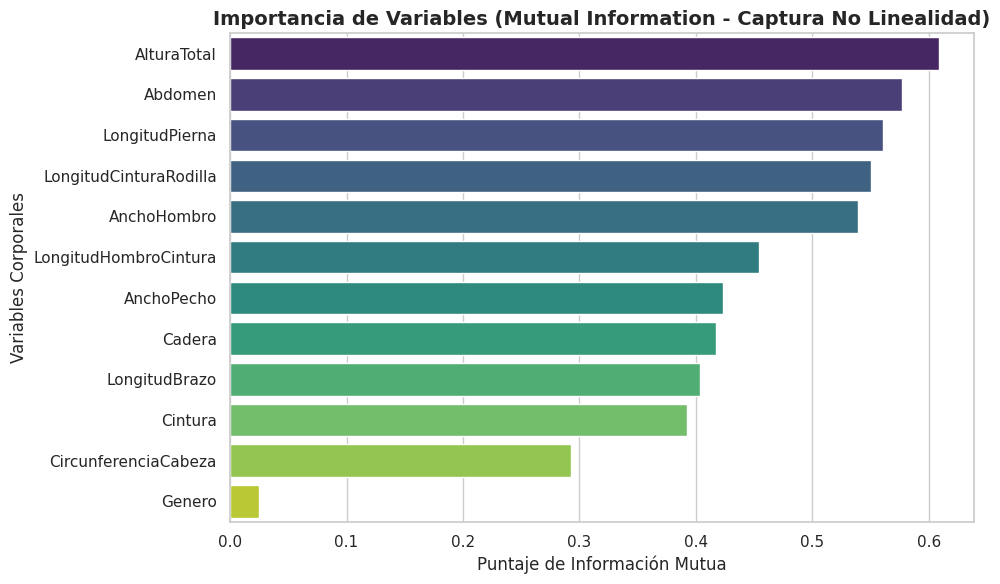

In [36]:
# Calcular Mutual Information
X = dataset_bmd.drop('Edad', axis=1)
y = dataset_bmd['Edad']

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Gráfico de Información Mutua
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette='viridis')
plt.title('Importancia de Variables (Mutual Information - Captura No Linealidad)', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje de Información Mutua', fontsize=12)
plt.ylabel('Variables Corporales', fontsize=12)
plt.tight_layout()
plt.show()

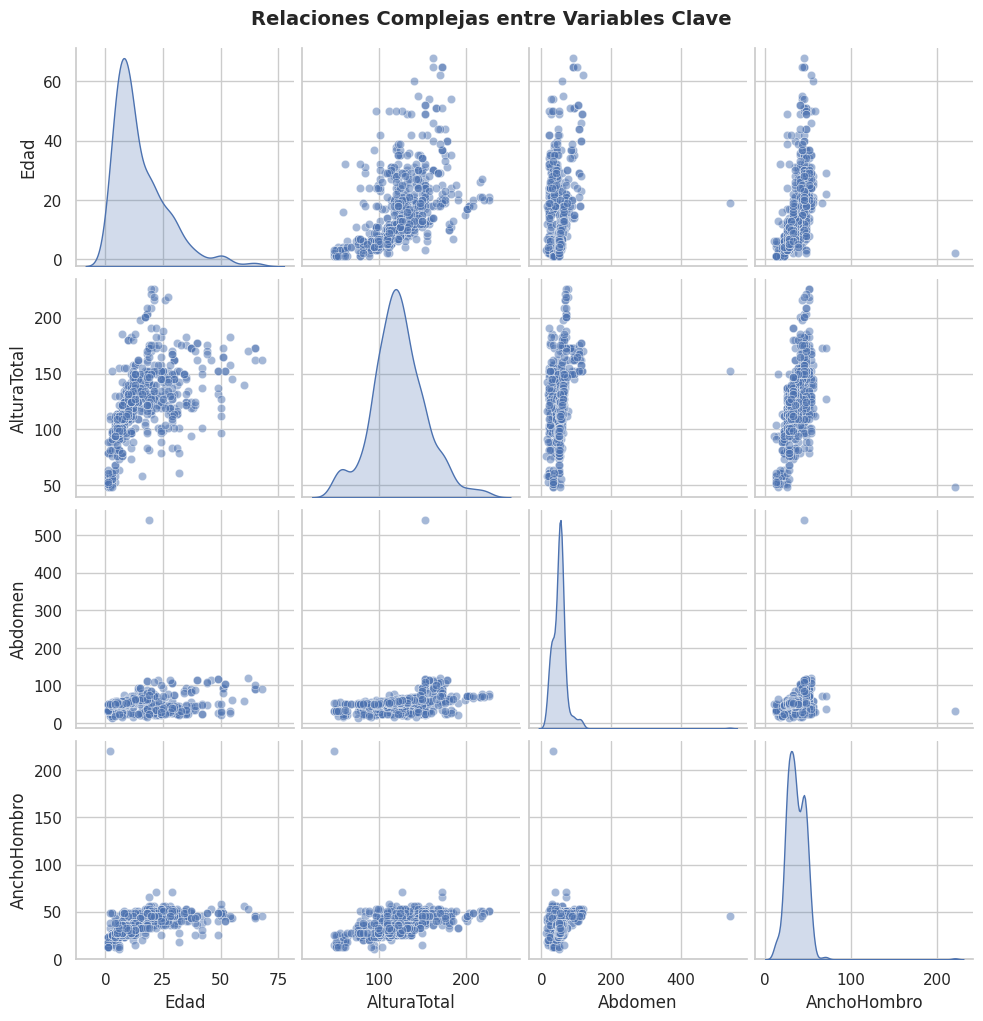

In [35]:
# Pairplot de relaciones no lineales (Mostramos solo las 3 mejores + Edad para no saturar la RAM)
variables_clave = ['Edad', 'AlturaTotal', 'Abdomen', 'AnchoHombro']
sns.pairplot(dataset_bmd[variables_clave], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Relaciones Complejas entre Variables Clave', y=1.02, fontsize=14, fontweight='bold')
plt.show()

La `AlturaTotal` demuestra ser la variable con mas información, `Abdomen` y `AnchoHombro` son predictores muy fuertes de edad. `Genero` no aporta valor predictivo para determinar la edad.